# 📊 Notebook 03: Feature Engineering — Technical Indicators

---

## 🎯 Objective

Technical indicators are mathematical transformations of price and volume data that traders use to predict future price movements. In this notebook, we will:

1. **Calculate indicators manually** (from scratch, no libraries) to deeply understand the math
2. **Verify** our calculations against the `pandas_ta` library
3. **Visualize** each indicator with buy/sell signals
4. **Analyze** how indicators behaved during COVID and the Oct 2024 crash

### Why Manual Calculation?
> Using a library is easy. Understanding *why* RSI = 30 means "oversold" requires building it from scratch.

We'll implement: **RSI, MACD, Bollinger Bands, OBV, and ATR**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

PROCESSED_DIR = '../data/processed'
print("Environment ready")

Environment ready


## 1. Load Cleaned Data

In [2]:
import os
import pandas as pd

# 1. Construct the path safely using os.path.join
# This automatically handles backslashes correctly for Windows
file_path = os.path.join(PROCESSED_DIR, 'tata_motors_clean.csv')

# Debug: Print where we are looking
print(f"Looking for file at: {os.path.abspath(file_path)}\n")

try:
    # 2. Load the data using the safe path variable
    if not os.path.exists(file_path):
        # Fallback: Try absolute path with FORWARD slashes (safe in Python)
        file_path = 'D:/stock/stock project dnyanesh/stock_app/data/processed/tata_motors_clean.csv'
        print(f"⚠️ Initial path failed. Trying absolute path: {file_path}")

    df = pd.read_csv(file_path, index_col=0, parse_dates=True)
    print("✅ Successfully loaded from CSV.")

except FileNotFoundError:
    print(f"❌ ERROR: File not found at: {file_path}")
    print("Please ensure you have run Notebook 01 to generate the data.")
    df = pd.DataFrame() # Avoid crashing later cells

# 3. Validation
if not df.empty:
    # Ensure we have the essential columns
    essential_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    missing_cols = [c for c in essential_cols if c not in df.columns]
    
    if missing_cols:
        print(f"⚠️ WARNING: Missing columns: {missing_cols}")
    else:
        print("-" * 40)
        print(f"Data Shape: {df.shape}")
        print(f"Date Range: {df.index.min().date()} to {df.index.max().date()}")
        print(f"Columns: {list(df.columns[:8])}")
        
    # Display first 5 rows
    try:
        display(df.head())
    except NameError:
        print(df.head())

Looking for file at: d:\stock\stock project dnyanesh\stock_app\data\processed\tata_motors_clean.csv

✅ Successfully loaded from CSV.
----------------------------------------
Data Shape: (85, 7)
Date Range: 2025-10-15 to 2026-02-17
Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'Regime', 'Returns']


,Close,High,Low,Open,Volume,Regime,Returns
Date,,,,,,,
2025-10-15,390.850006,403.000000,388.000000,403.000000,26953550,Oct 2024 Crash,NaN
2025-10-16,396.799988,400.450012,389.549988,395.450012,21983750,Oct 2024 Crash,0.015223
2025-10-17,396.600006,402.500000,392.250000,396.799988,16564540,Oct 2024 Crash,-0.000504
2025-10-20,399.750000,403.399994,396.600006,400.049988,10471670,Oct 2024 Crash,0.007942
2025-10-21,401.850006,403.399994,400.049988,402.799988,3449156,Oct 2024 Crash,0.005253


## 2. RSI — Relative Strength Index

### Theory

RSI measures the **speed and magnitude** of price changes to evaluate overbought or oversold conditions.

**Mathematical Formula:**

$$RSI = 100 - \frac{100}{1 + RS}$$

Where:
$$RS = \frac{\text{Average Gain over } n \text{ periods}}{\text{Average Loss over } n \text{ periods}}$$

**Interpretation:**
- RSI > 70: **Overbought** — Price has risen too fast, might reverse down
- RSI < 30: **Oversold** — Price has fallen too fast, might bounce back
- RSI = 50: **Neutral** — No strong signal

**Standard period:** n = 14 days (proposed by J. Welles Wilder in 1978)

### Step-by-Step Calculation:
1. Calculate daily price change: $\Delta P = Close_t - Close_{t-1}$
2. Separate into gains and losses
3. Calculate average gain and loss using exponential smoothing
4. Compute RS and then RSI


In [3]:
# First, let's verify what is actually inside 'df' right now
if 'Close' in df.columns:
    # Step 1: Calculate daily price changes
    df['Price_Change'] = df['Close'].diff()

    print("Step 1: Daily Price Changes")
    print(df[['Close', 'Price_Change']].head(10))
    print(f"\nPositive (gain) days: {(df['Price_Change'] > 0).sum()}")
    print(f"Negative (loss) days: {(df['Price_Change'] < 0).sum()}")
    print(f"Zero change days:     {(df['Price_Change'] == 0).sum()}")
    
elif df.empty:
    print("ERROR: Your DataFrame 'df' is completely empty.")
    print("You need to successfully load your stock data (from the CSV or dictionary) before running this calculation.")
    
else:
    print("ERROR: The 'Close' column is missing from your DataFrame!")
    print(f"Current columns in df: {list(df.columns)}")
    print(f"DataFrame shape: {df.shape}")

Step 1: Daily Price Changes
                 Close  Price_Change
Date                                
2025-10-15  390.850006           NaN
2025-10-16  396.799988      5.949982
2025-10-17  396.600006     -0.199982
2025-10-20  399.750000      3.149994
2025-10-21  401.850006      2.100006
2025-10-23  405.850006      4.000000
2025-10-24  403.299988     -2.550018
2025-10-27  410.049988      6.750000
2025-10-28  411.500000      1.450012
2025-10-29  411.350006     -0.149994

Positive (gain) days: 36
Negative (loss) days: 48
Zero change days:     0


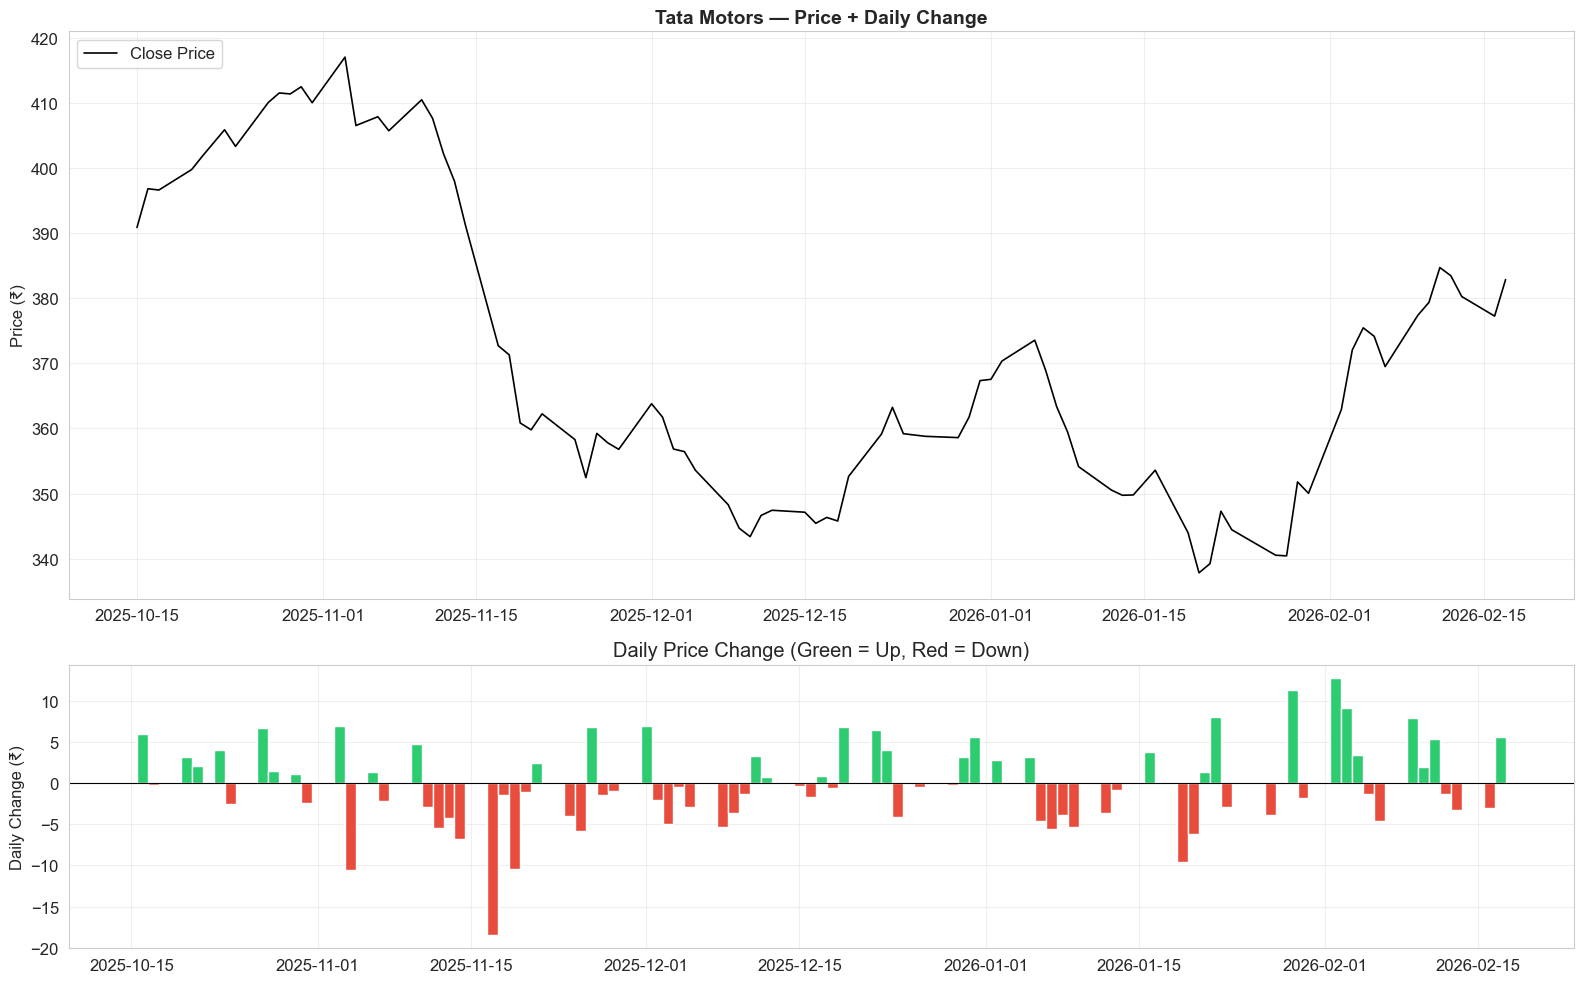

In [4]:
# Visualize Daily Price Change (Up vs Down Days)
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [2, 1]})

# Top Panel: Price
ax = axes[0]
ax.plot(df.index, df['Close'], color='black', linewidth=1.2, label='Close Price')
ax.set_title('Tata Motors — Price + Daily Change', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (₹)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Bottom Panel: Price Change (Diff)
ax = axes[1]
# Color bars: Green for Up days, Red for Down days
colors = ['#2ECC71' if x >= 0 else '#E74C3C' for x in df['Price_Change']]
ax.bar(df.index, df['Price_Change'], color=colors, width=1.0)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Daily Change (₹)')
ax.set_title('Daily Price Change (Green = Up, Red = Down)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Step 2: Separate gains and losses
df['Gain'] = df['Price_Change'].apply(lambda x: x if x > 0 else 0)
df['Loss'] = df['Price_Change'].apply(lambda x: abs(x) if x < 0 else 0)

print("Step 2: Gains and Losses Separated")
print(df[['Close', 'Price_Change', 'Gain', 'Loss']].head(10))

Step 2: Gains and Losses Separated
                 Close  Price_Change      Gain      Loss
Date                                                    
2025-10-15  390.850006           NaN  0.000000  0.000000
2025-10-16  396.799988      5.949982  5.949982  0.000000
2025-10-17  396.600006     -0.199982  0.000000  0.199982
2025-10-20  399.750000      3.149994  3.149994  0.000000
2025-10-21  401.850006      2.100006  2.100006  0.000000
2025-10-23  405.850006      4.000000  4.000000  0.000000
2025-10-24  403.299988     -2.550018  0.000000  2.550018
2025-10-27  410.049988      6.750000  6.750000  0.000000
2025-10-28  411.500000      1.450012  1.450012  0.000000
2025-10-29  411.350006     -0.149994  0.000000  0.149994


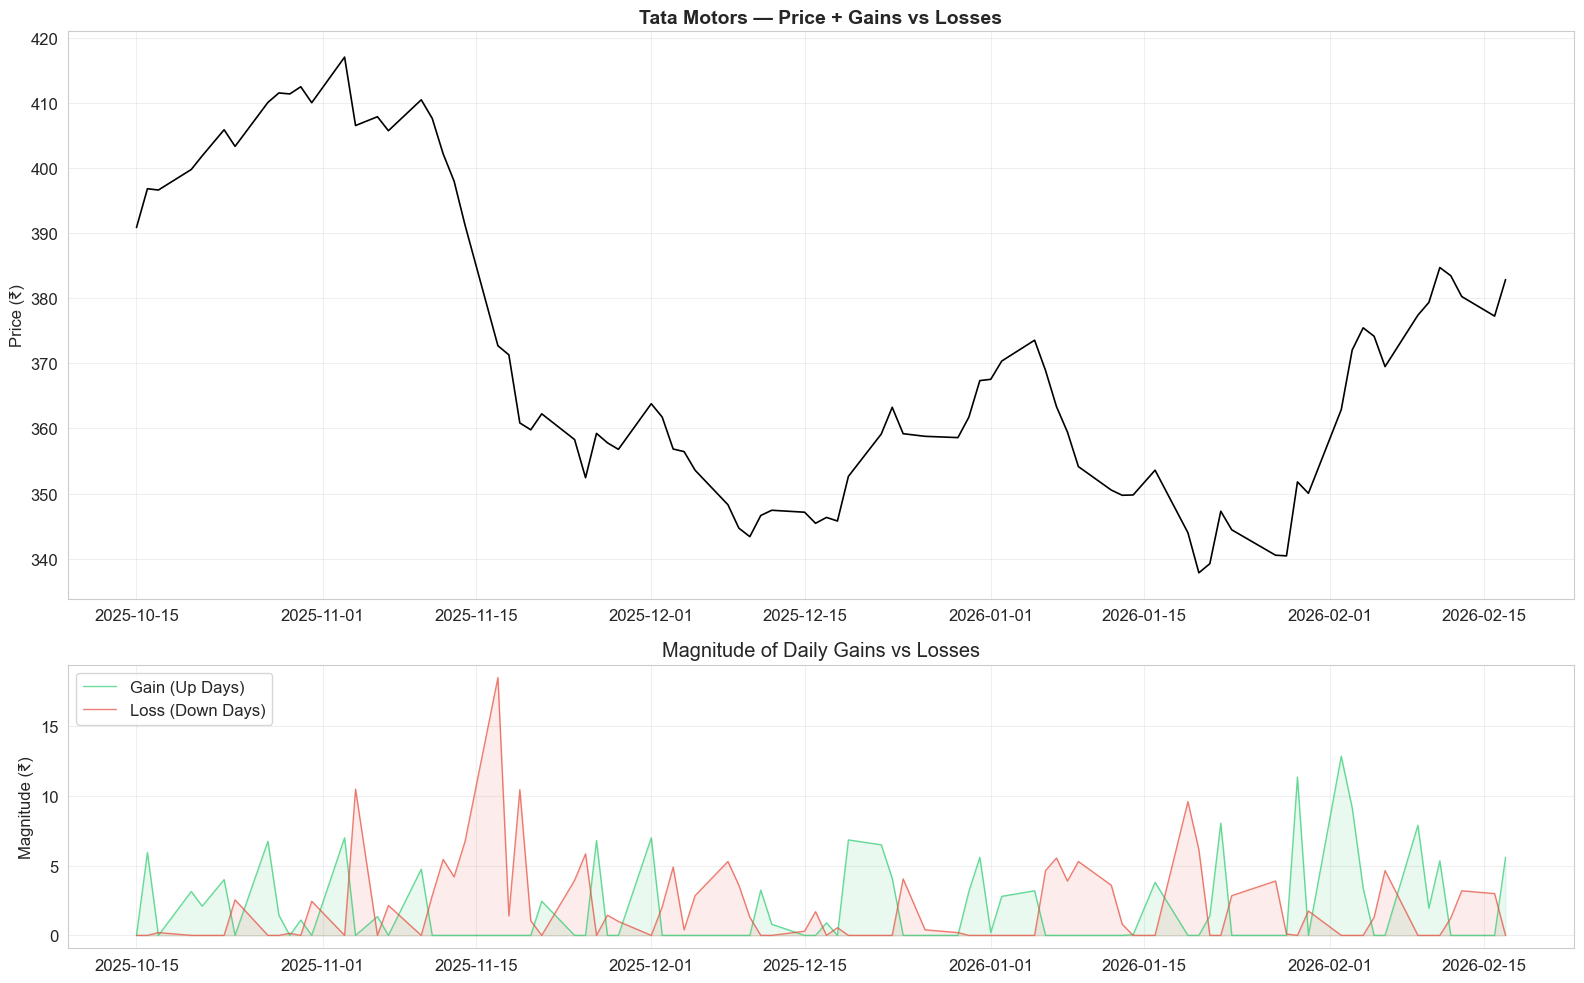

In [6]:
# Visualize Gains vs Losses (Absolute Magnitude)
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [2, 1]})

# Top Panel: Price
ax = axes[0]
ax.plot(df.index, df['Close'], color='black', linewidth=1.2)
ax.set_title('Tata Motors — Price + Gains vs Losses', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (₹)')
ax.grid(True, alpha=0.3)

# Bottom Panel: Gains and Losses Stacked
ax = axes[1]
ax.plot(df.index, df['Gain'], color='#2ECC71', linewidth=1, label='Gain (Up Days)', alpha=0.7)
ax.plot(df.index, df['Loss'], color='#E74C3C', linewidth=1, label='Loss (Down Days)', alpha=0.7)
ax.fill_between(df.index, 0, df['Gain'], color='#2ECC71', alpha=0.1)
ax.fill_between(df.index, 0, df['Loss'], color='#E74C3C', alpha=0.1)

ax.set_ylabel('Magnitude (₹)')
ax.set_title('Magnitude of Daily Gains vs Losses')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Step 3: Calculate Average Gain/Loss (Wilder's Smoothing Method)
# Wilder's smoothing is an exponential moving average with alpha = 1/n
period = 14

df['Avg_Gain'] = df['Gain'].ewm(alpha=1/period, min_periods=period).mean()
df['Avg_Loss'] = df['Loss'].ewm(alpha=1/period, min_periods=period).mean()

print("Step 3: Smoothed Average Gain/Loss")
print(df[['Gain', 'Avg_Gain', 'Loss', 'Avg_Loss']].dropna().head(10))

Step 3: Smoothed Average Gain/Loss
                Gain  Avg_Gain       Loss  Avg_Loss
Date                                               
2025-11-04  0.000000  2.206371  10.500000  1.585349
2025-11-06  1.350006  2.115207   0.000000  1.416581
2025-11-07  0.000000  1.897653   2.149994  1.492014
2025-11-10  4.750000  2.182086   0.000000  1.343232
2025-11-11  0.000000  1.970477   2.850006  1.489352
2025-11-12  0.000000  1.784149   5.450012  1.863871
2025-11-13  0.000000  1.619255   4.199982  2.079779
2025-11-14  0.000000  1.472677   6.750000  2.502534
2025-11-17  0.000000  1.341866  18.500000  3.923519
2025-11-18  0.000000  1.224712   1.400024  3.703201


In [8]:
# Step 4: Calculate RS and RSI
df['RS'] = df['Avg_Gain'] / df['Avg_Loss']
df['RSI_Manual'] = 100 - (100 / (1 + df['RS']))

# Handle edge case: when Avg_Loss = 0, RS = infinity, RSI = 100
df['RSI_Manual'] = df['RSI_Manual'].clip(0, 100)

print("Step 4: RS and RSI")
print(df[['Avg_Gain', 'Avg_Loss', 'RS', 'RSI_Manual']].dropna().head(10))

Step 4: RS and RSI
            Avg_Gain  Avg_Loss        RS  RSI_Manual
Date                                                
2025-11-04  2.206371  1.585349  1.391726   58.189189
2025-11-06  2.115207  1.416581  1.493178   59.890547
2025-11-07  1.897653  1.492014  1.271873   55.983460
2025-11-10  2.182086  1.343232  1.624504   61.897560
2025-11-11  1.970477  1.489352  1.323043   56.953015
2025-11-12  1.784149  1.863871  0.957228   48.907328
2025-11-13  1.619255  2.079779  0.778571   43.775076
2025-11-14  1.472677  2.502534  0.588474   37.046513
2025-11-17  1.341866  3.923519  0.342006   25.484669
2025-11-18  1.224712  3.703201  0.330717   24.852549


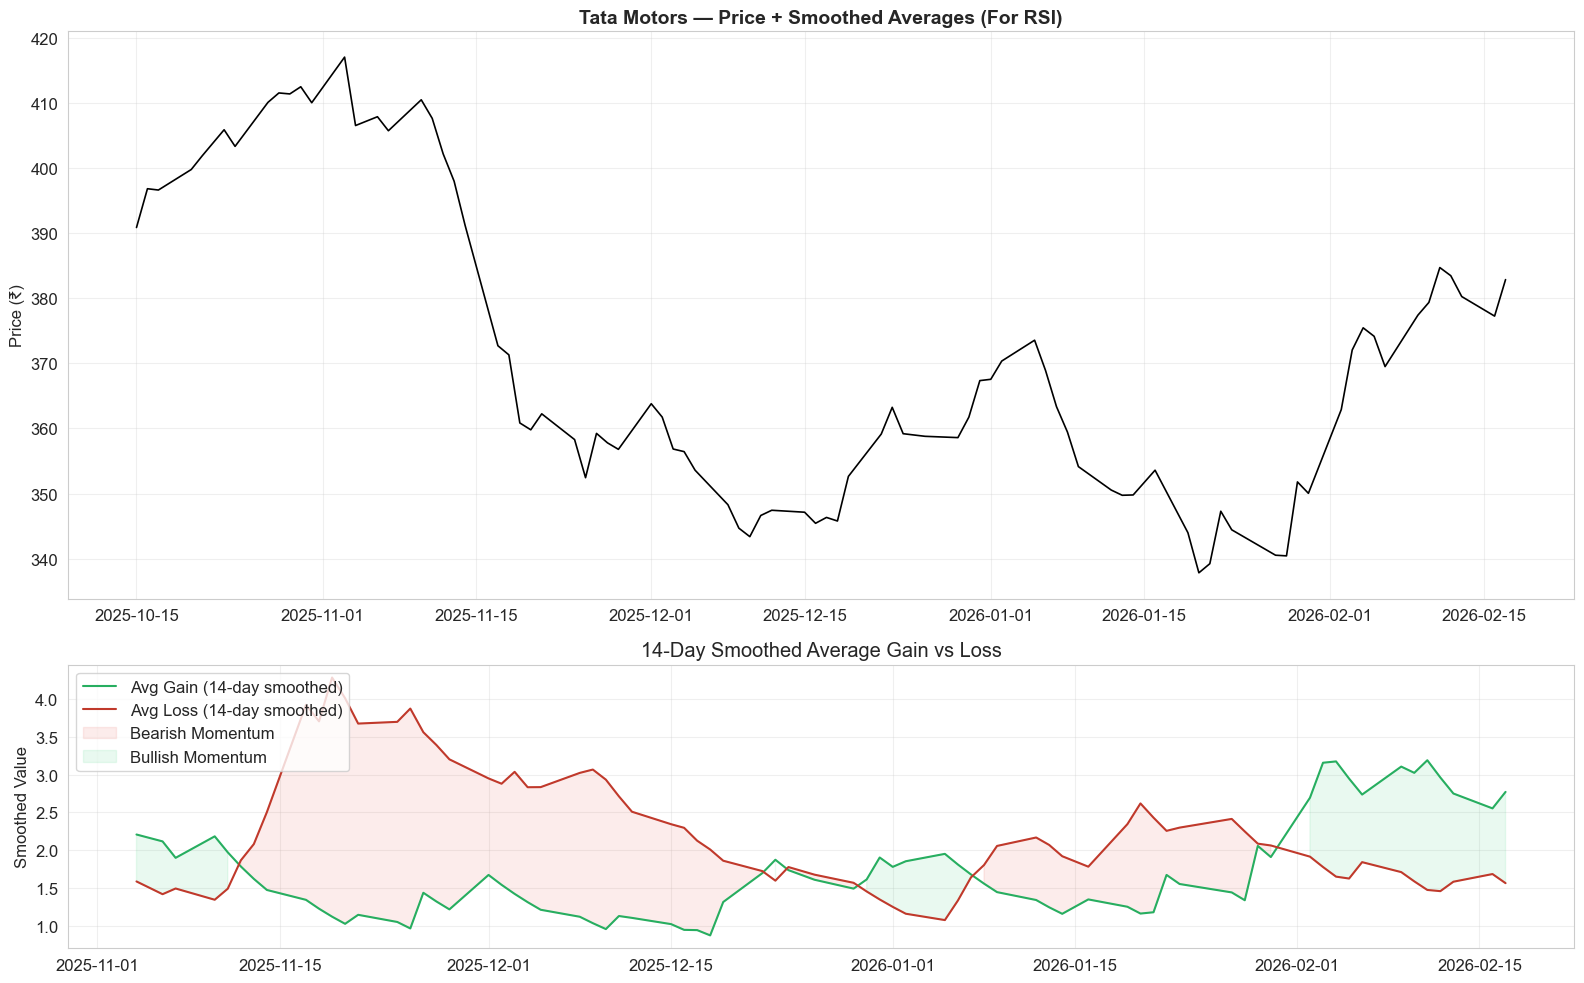

In [9]:
# Visualize Smoothed Average Gain/Loss (Wilder's Smoothing)
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [2, 1]})

# Top Panel: Price
ax = axes[0]
ax.plot(df.index, df['Close'], color='black', linewidth=1.2)
ax.set_title('Tata Motors — Price + Smoothed Averages (For RSI)', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (₹)')
ax.grid(True, alpha=0.3)

# Bottom Panel: Avg Gain vs Avg Loss
ax = axes[1]
ax.plot(df.index, df['Avg_Gain'], color='#27AE60', linewidth=1.5, label='Avg Gain (14-day smoothed)')
ax.plot(df.index, df['Avg_Loss'], color='#C0392B', linewidth=1.5, label='Avg Loss (14-day smoothed)')

# Highlight periods where Avg Loss > Avg Gain (Bearish Momentum)
ax.fill_between(df.index, df['Avg_Gain'], df['Avg_Loss'], 
                where=(df['Avg_Loss'] > df['Avg_Gain']), 
                color='#E74C3C', alpha=0.1, label='Bearish Momentum')

# Highlight periods where Avg Gain > Avg Loss (Bullish Momentum)
ax.fill_between(df.index, df['Avg_Gain'], df['Avg_Loss'], 
                where=(df['Avg_Gain'] > df['Avg_Loss']), 
                color='#2ECC71', alpha=0.1, label='Bullish Momentum')

ax.set_ylabel('Smoothed Value')
ax.set_title('14-Day Smoothed Average Gain vs Loss')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

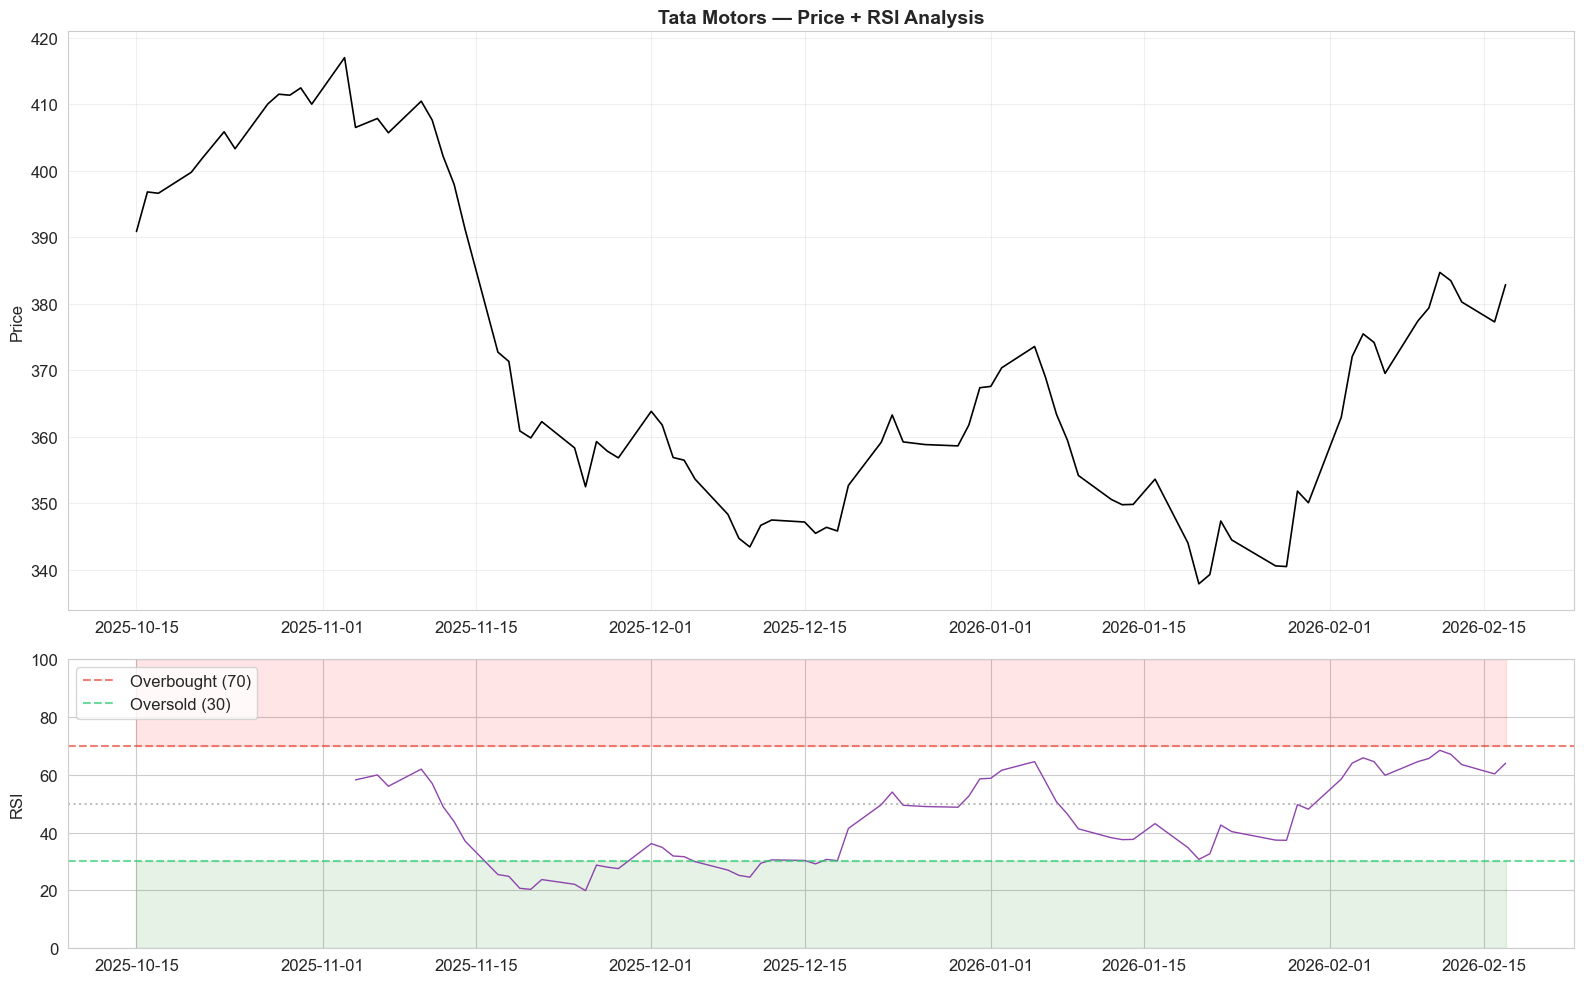

In [10]:
# Visualize RSI
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [2, 1]})

# Price
ax = axes[0]
ax.plot(df.index, df['Close'], color='black', linewidth=1.2)
ax.set_title('Tata Motors — Price + RSI Analysis', fontsize=14, fontweight='bold')
ax.set_ylabel('Price')
ax.grid(True, alpha=0.3)

# RSI
ax = axes[1]
ax.plot(df.index, df['RSI_Manual'], color='#8E44AD', linewidth=1)
ax.axhline(70, color='#E74C3C', linestyle='--', alpha=0.7, label='Overbought (70)')
ax.axhline(30, color='#2ECC71', linestyle='--', alpha=0.7, label='Oversold (30)')
ax.axhline(50, color='gray', linestyle=':', alpha=0.5)
ax.fill_between(df.index, 70, 100, alpha=0.1, color='red')
ax.fill_between(df.index, 0, 30, alpha=0.1, color='green')
ax.set_ylabel('RSI')
ax.set_ylim(0, 100)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'rsi_chart.png'), dpi=150, bbox_inches='tight')
plt.show()

### RSI Analysis — Key Observations

1. **COVID Crash (Mar 2020):** RSI plunged below 20 — extreme oversold territory. This was a strong "buy" signal in hindsight.
2. **Recovery Rally (2020-2021):** RSI frequently touched 70+ — the stock was consistently in overbought territory during the rally.
3. **Oct 2024:** Did RSI signal the crash before it happened? Look for divergence — if price made new highs but RSI made lower highs, that's a **bearish divergence** warning.

> **Key Insight:** RSI is a *momentum* indicator. It tells you HOW FAST the price is moving, not WHERE it will go.


## 3. MACD — Moving Average Convergence Divergence

### Theory

MACD captures **trend changes** by comparing two exponential moving averages (EMAs).

**Components:**
1. **MACD Line:** $EMA_{12} - EMA_{26}$ (difference between fast and slow EMAs)
2. **Signal Line:** $EMA_9(MACD\ Line)$ (smoothed version of MACD)
3. **Histogram:** $MACD\ Line - Signal\ Line$ (momentum)

**Trading Signals:**
- **Bullish Crossover:** MACD crosses ABOVE Signal Line = Buy
- **Bearish Crossover:** MACD crosses BELOW Signal Line = Sell
- **Histogram Divergence:** When histogram shrinks while price makes new highs = warning

### EMA Formula:
$$EMA_t = Price_t \times \alpha + EMA_{t-1} \times (1 - \alpha)$$

Where $\alpha = \frac{2}{n + 1}$ and $n$ is the number of periods.


In [11]:
# Calculate MACD components
df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD_Line'] = df['EMA_12'] - df['EMA_26']
df['Signal_Line'] = df['MACD_Line'].ewm(span=9, adjust=False).mean()
df['MACD_Histogram'] = df['MACD_Line'] - df['Signal_Line']

print("MACD Components Calculated")
print(df[['Close', 'EMA_12', 'EMA_26', 'MACD_Line', 'Signal_Line', 'MACD_Histogram']].dropna().tail(10))

MACD Components Calculated
                 Close      EMA_12      EMA_26  MACD_Line  Signal_Line  \
Date                                                                     
2026-02-04  375.450012  356.832988  355.606421   1.226567    -2.327248   
2026-02-05  374.149994  359.497142  356.980019   2.517123    -1.358374   
2026-02-06  369.500000  361.036044  357.907425   3.128619    -0.460975   
2026-02-09  377.399994  363.553574  359.351319   4.202255     0.471671   
2026-02-10  379.350006  365.983795  360.832703   5.151091     1.407555   
2026-02-11  384.700012  368.863213  362.600652   6.262561     2.378556   
2026-02-12  383.450012  371.107336  364.145049   6.962287     3.295302   
2026-02-13  380.250000  372.513899  365.338008   7.175891     4.071420   
2026-02-16  377.250000  373.242530  366.220378   7.022152     4.661566   
2026-02-17  382.850006  374.720604  367.452202   7.268401     5.182933   

            MACD_Histogram  
Date                        
2026-02-04        3.553815

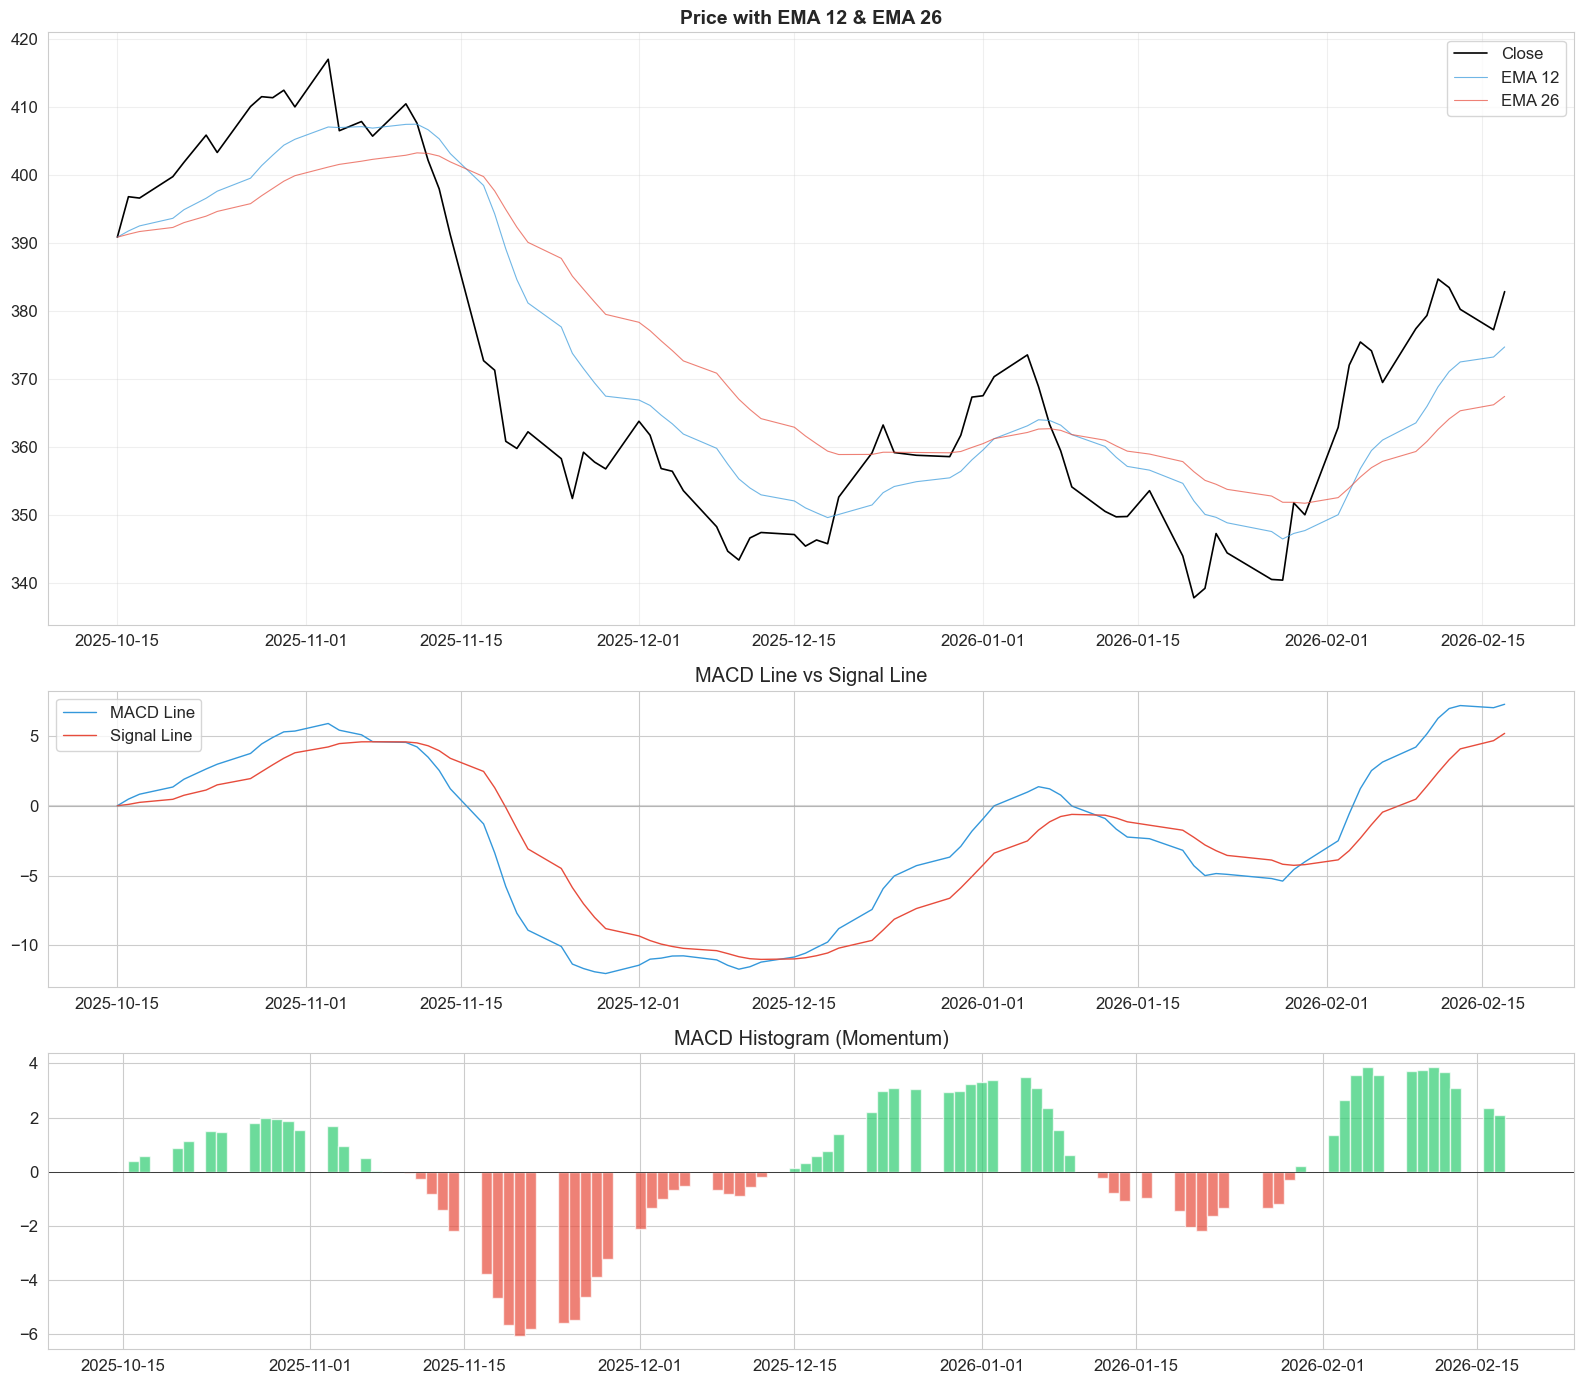

In [12]:
# Visualize MACD
fig, axes = plt.subplots(3, 1, figsize=(16, 14), gridspec_kw={'height_ratios': [2, 1, 1]})

# Price with EMAs
ax = axes[0]
ax.plot(df.index, df['Close'], color='black', linewidth=1.2, label='Close')
ax.plot(df.index, df['EMA_12'], color='#3498DB', linewidth=0.8, alpha=0.7, label='EMA 12')
ax.plot(df.index, df['EMA_26'], color='#E74C3C', linewidth=0.8, alpha=0.7, label='EMA 26')
ax.set_title('Price with EMA 12 & EMA 26', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# MACD Line + Signal
ax = axes[1]
ax.plot(df.index, df['MACD_Line'], color='#3498DB', linewidth=1, label='MACD Line')
ax.plot(df.index, df['Signal_Line'], color='#E74C3C', linewidth=1, label='Signal Line')
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_title('MACD Line vs Signal Line')
ax.legend()

# Histogram
ax = axes[2]
colors = ['#2ECC71' if v >= 0 else '#E74C3C' for v in df['MACD_Histogram']]
ax.bar(df.index, df['MACD_Histogram'], color=colors, alpha=0.7, width=1)
ax.set_title('MACD Histogram (Momentum)')
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'macd_chart.png'), dpi=150, bbox_inches='tight')
plt.show()

### MACD Analysis

- **Bullish crossovers** (MACD > Signal) during 2020-2021 recovery were strong buy signals
- **Bearish crossovers** around Oct 2024 preceded the crash
- The **histogram** shows momentum: when it shrinks → trend is weakening, even if price is still rising


## 4. Bollinger Bands

### Theory

Bollinger Bands measure **volatility** by creating an envelope around the price.

**Formula:**
- **Middle Band:** $SMA_{20}$ (20-day Simple Moving Average)
- **Upper Band:** $SMA_{20} + 2 \times \sigma_{20}$
- **Lower Band:** $SMA_{20} - 2 \times \sigma_{20}$

Where $\sigma_{20}$ is the 20-day rolling standard deviation.

**Interpretation:**
- Price touching Upper Band = potentially overbought
- Price touching Lower Band = potentially oversold
- **Band Width** = $(Upper - Lower) / Middle$ — measures volatility
- Narrow bands ("squeeze") often precede big moves


In [13]:
# Calculate Bollinger Bands
window = 20
df['BB_Middle'] = df['Close'].rolling(window=window).mean()
df['BB_Std'] = df['Close'].rolling(window=window).std()
df['BB_Upper'] = df['BB_Middle'] + 2 * df['BB_Std']
df['BB_Lower'] = df['BB_Middle'] - 2 * df['BB_Std']
df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['BB_Middle']

# Band touch signals
df['BB_Upper_Touch'] = df['Close'] >= df['BB_Upper']
df['BB_Lower_Touch'] = df['Close'] <= df['BB_Lower']

print(f"Upper band touches: {df['BB_Upper_Touch'].sum()}")
print(f"Lower band touches: {df['BB_Lower_Touch'].sum()}")

Upper band touches: 1
Lower band touches: 6


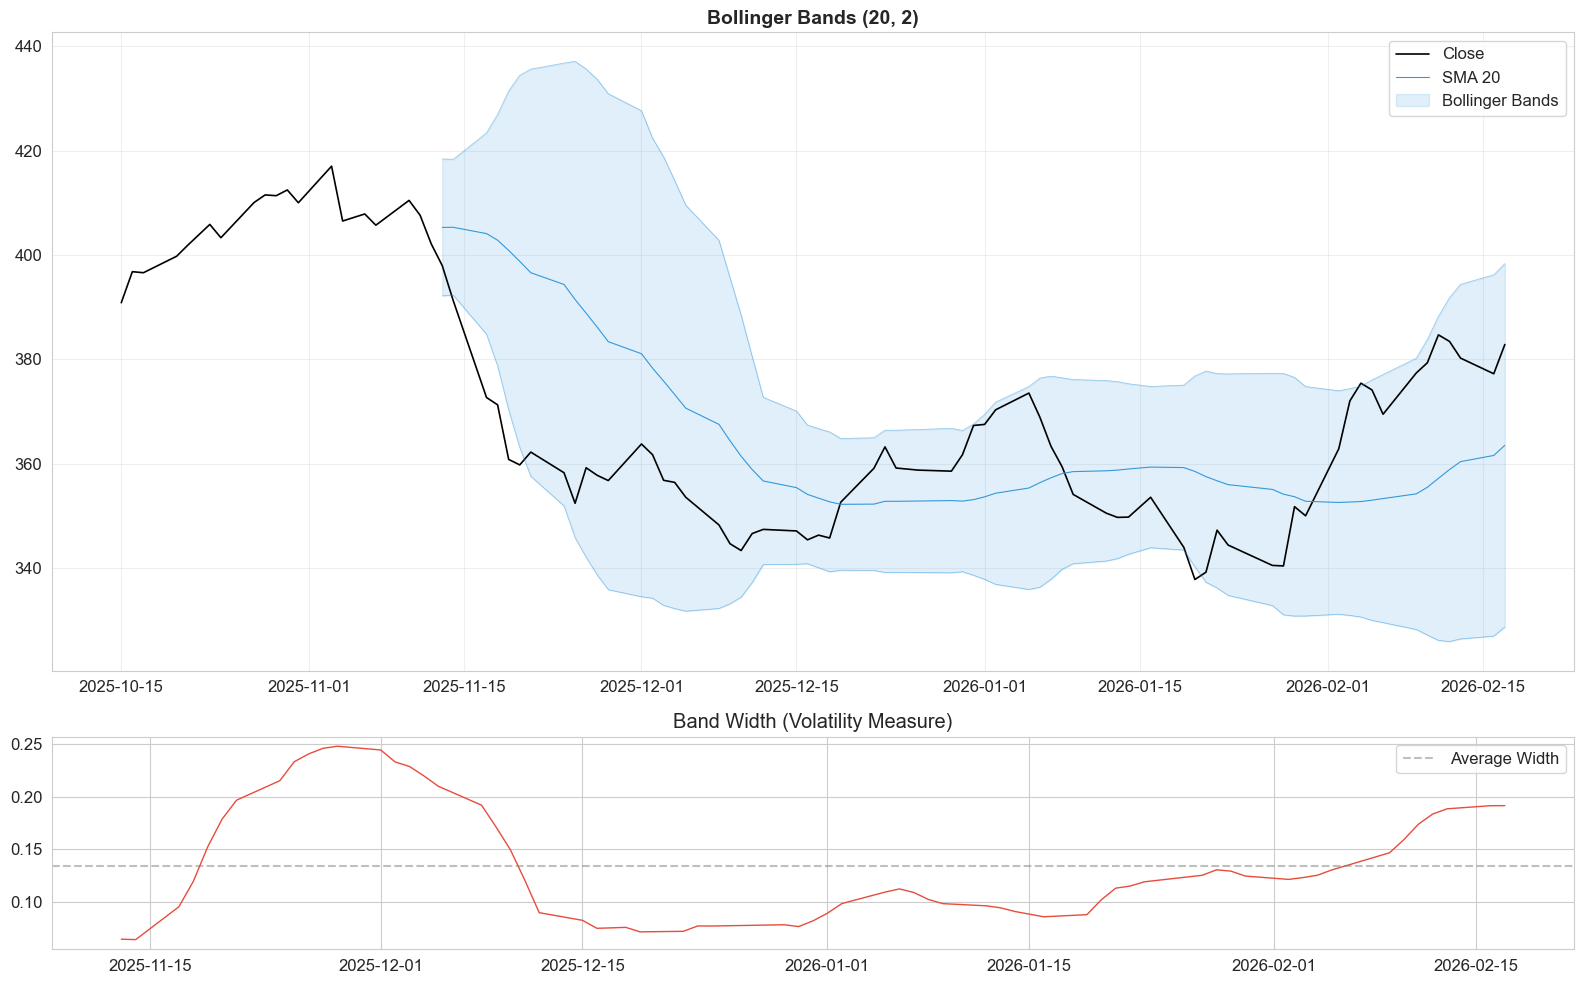

In [14]:
# Visualize Bollinger Bands
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.plot(df.index, df['Close'], color='black', linewidth=1.2, label='Close')
ax.plot(df.index, df['BB_Middle'], color='#3498DB', linewidth=0.8, label='SMA 20')
ax.fill_between(df.index, df['BB_Upper'], df['BB_Lower'], alpha=0.15, color='#3498DB', label='Bollinger Bands')
ax.plot(df.index, df['BB_Upper'], color='#3498DB', linewidth=0.5, alpha=0.5)
ax.plot(df.index, df['BB_Lower'], color='#3498DB', linewidth=0.5, alpha=0.5)
ax.set_title('Bollinger Bands (20, 2)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df.index, df['BB_Width'], color='#E74C3C', linewidth=1)
ax.set_title('Band Width (Volatility Measure)')
ax.axhline(df['BB_Width'].mean(), color='gray', linestyle='--', alpha=0.5, label='Average Width')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'bollinger_chart.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. OBV — On-Balance Volume

### Theory

OBV links **volume to price direction**. The idea: volume precedes price.

**Formula:**
$$OBV_t = OBV_{t-1} + \begin{cases} Volume_t & \text{if } Close_t > Close_{t-1} \\ -Volume_t & \text{if } Close_t < Close_{t-1} \\ 0 & \text{if } Close_t = Close_{t-1} \end{cases}$$

**Why it matters:** If OBV is rising while price is flat, it means "smart money" is accumulating — a bullish signal. If OBV is falling while price is stable, distribution is happening.


In [15]:
# Calculate OBV
df['OBV'] = 0.0
for i in range(1, len(df)):
    if df['Close'].iloc[i] > df['Close'].iloc[i-1]:
        df.iloc[i, df.columns.get_loc('OBV')] = df['OBV'].iloc[i-1] + df['Volume'].iloc[i]
    elif df['Close'].iloc[i] < df['Close'].iloc[i-1]:
        df.iloc[i, df.columns.get_loc('OBV')] = df['OBV'].iloc[i-1] - df['Volume'].iloc[i]
    else:
        df.iloc[i, df.columns.get_loc('OBV')] = df['OBV'].iloc[i-1]

# Normalize for easier visualization
df['OBV_Normalized'] = (df['OBV'] - df['OBV'].min()) / (df['OBV'].max() - df['OBV'].min()) * 100

print("OBV calculated")
print(df[['Close', 'Volume', 'OBV']].tail(10))

OBV calculated
                 Close    Volume          OBV
Date                                         
2026-02-04  375.450012  10142350  -80916383.0
2026-02-05  374.149994  14013830  -94930213.0
2026-02-06  369.500000  23116970 -118047183.0
2026-02-09  377.399994   8800284 -109246899.0
2026-02-10  379.350006   8921719 -100325180.0
2026-02-11  384.700012  10933650  -89391530.0
2026-02-12  383.450012   8324442  -97715972.0
2026-02-13  380.250000  15565860 -113281832.0
2026-02-16  377.250000   5004467 -118286299.0
2026-02-17  382.850006   7843059 -110443240.0


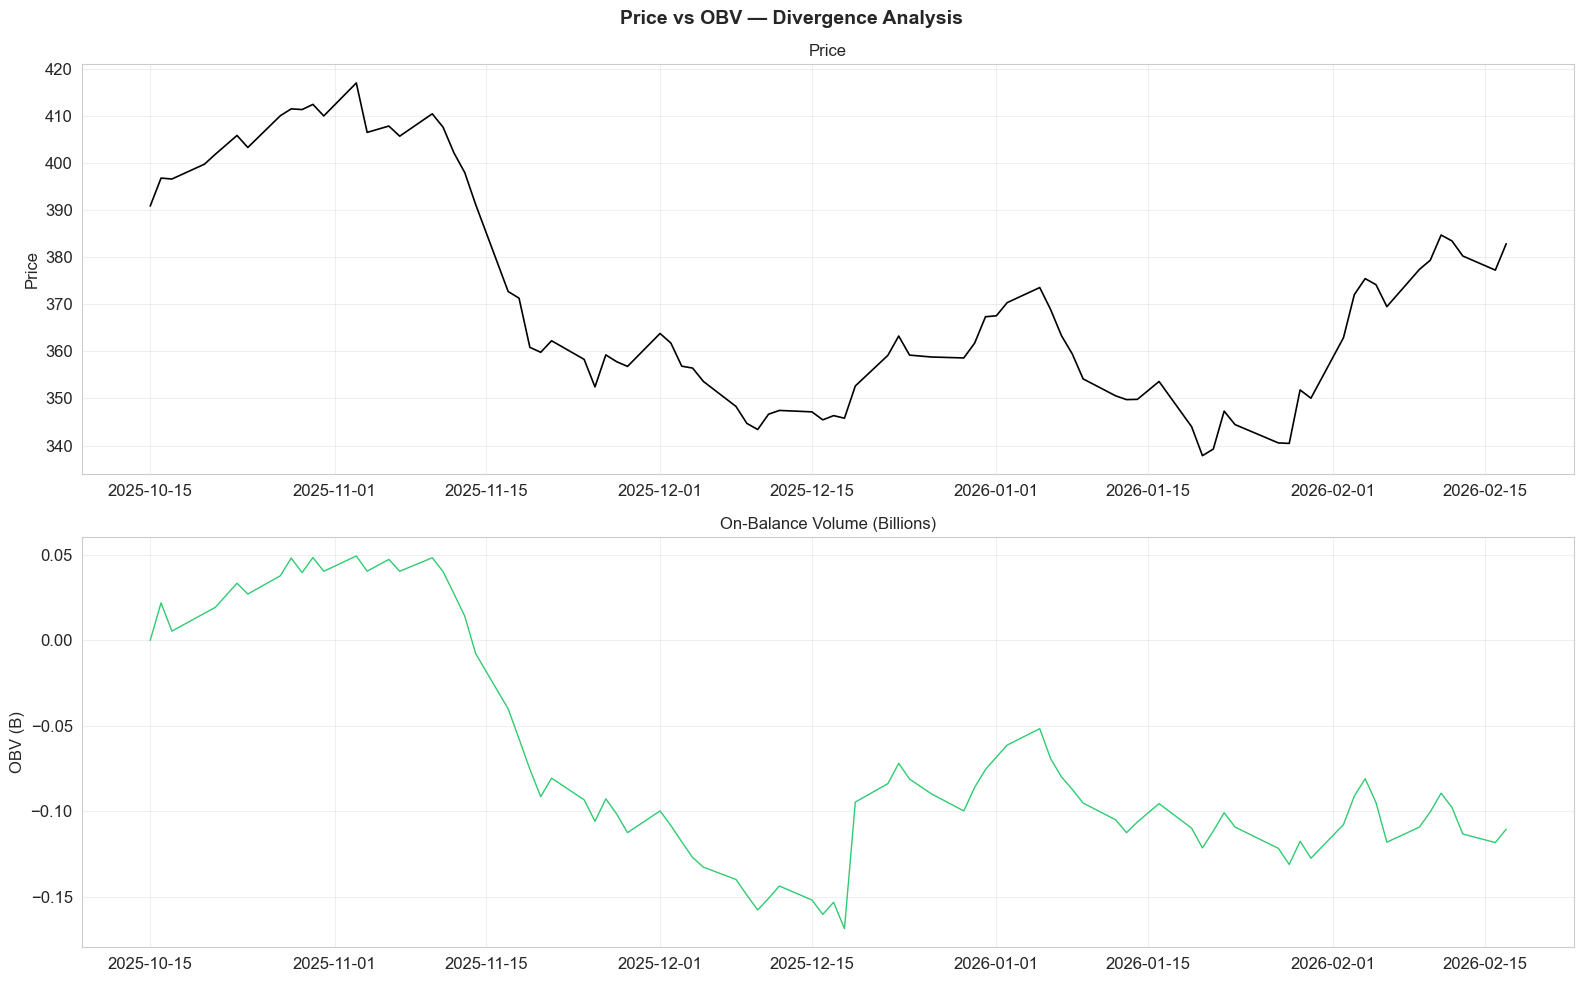


Look for DIVERGENCES:
  - Price UP + OBV DOWN = Bearish divergence (distribution)
  - Price DOWN + OBV UP = Bullish divergence (accumulation)


In [16]:
# OBV vs Price comparison
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [1, 1]})

axes[0].plot(df.index, df['Close'], color='black', linewidth=1.2)
axes[0].set_title('Price', fontsize=12)
axes[0].set_ylabel('Price')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df['OBV'] / 1e9, color='#2ECC71', linewidth=1)
axes[1].set_title('On-Balance Volume (Billions)', fontsize=12)
axes[1].set_ylabel('OBV (B)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Price vs OBV — Divergence Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nLook for DIVERGENCES:")
print("  - Price UP + OBV DOWN = Bearish divergence (distribution)")
print("  - Price DOWN + OBV UP = Bullish divergence (accumulation)")

## 6. ATR — Average True Range

### Theory

ATR measures **volatility** without caring about direction.

**True Range (TR):**
$$TR = \max(High - Low, |High - Close_{prev}|, |Low - Close_{prev}|)$$

**ATR:** $ATR = SMA_{14}(TR)$ or $EMA_{14}(TR)$

Higher ATR = more volatile (bigger daily swings), Lower ATR = calmer market.


In [17]:
# Calculate ATR
df['TR'] = np.maximum(
    df['High'] - df['Low'],
    np.maximum(
        abs(df['High'] - df['Close'].shift(1)),
        abs(df['Low'] - df['Close'].shift(1))
    )
)
df['ATR_14'] = df['TR'].rolling(window=14).mean()

print("ATR calculated")
print(df[['High', 'Low', 'Close', 'TR', 'ATR_14']].dropna().tail(10))

ATR calculated
                  High         Low       Close         TR     ATR_14
Date                                                                
2026-02-04  377.600006  368.450012  375.450012   9.149994  11.835717
2026-02-05  375.600006  364.299988  374.149994  11.300018  12.150005
2026-02-06  381.799988  361.000000  369.500000  20.799988  12.917860
2026-02-09  379.899994  369.600006  377.399994  10.399994  12.571431
2026-02-10  382.500000  376.750000  379.350006   5.750000  12.278573
2026-02-11  387.350006  382.100006  384.700012   8.000000  12.296430
2026-02-12  386.899994  380.149994  383.450012   6.750000  11.885716
2026-02-13  387.500000  374.399994  380.250000  13.100006  12.189287
2026-02-16  379.600006  375.100006  377.250000   5.149994  11.907144
2026-02-17  383.600006  373.549988  382.850006  10.050018  11.942858


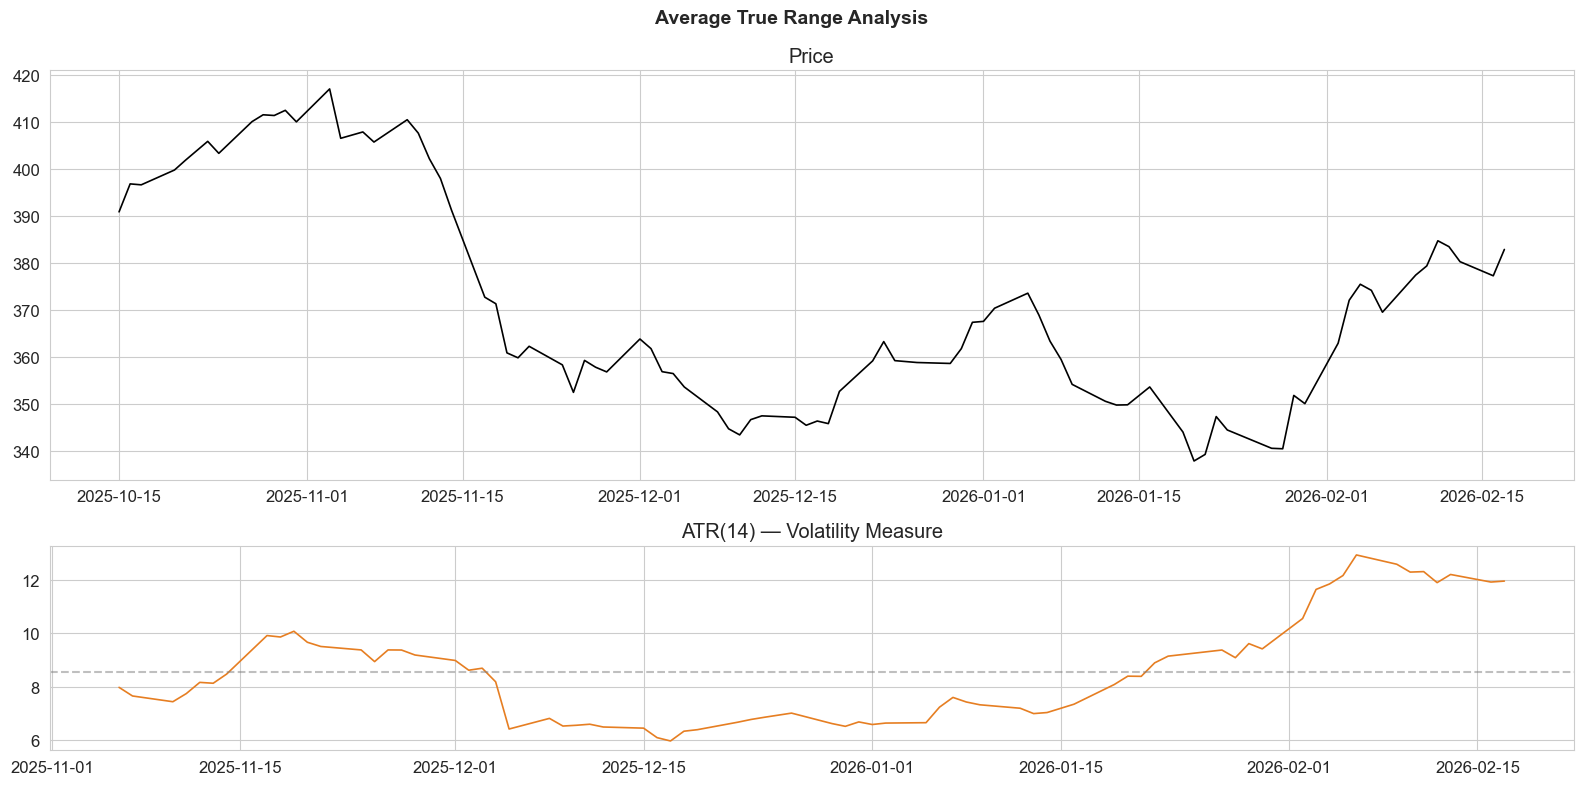


Current ATR: 11.94
Average ATR: 8.53
Max ATR (COVID crash likely): 12.92


In [18]:
# ATR Chart
fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [2, 1]})

axes[0].plot(df.index, df['Close'], color='black', linewidth=1.2)
axes[0].set_title('Price')

axes[1].plot(df.index, df['ATR_14'], color='#E67E22', linewidth=1.2)
axes[1].axhline(df['ATR_14'].mean(), color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('ATR(14) — Volatility Measure')

plt.suptitle('Average True Range Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nCurrent ATR: {df['ATR_14'].iloc[-1]:.2f}")
print(f"Average ATR: {df['ATR_14'].mean():.2f}")
print(f"Max ATR (COVID crash likely): {df['ATR_14'].max():.2f}")

## 7. Technical Indicator Dashboard

Let's create a comprehensive view showing all indicators together:


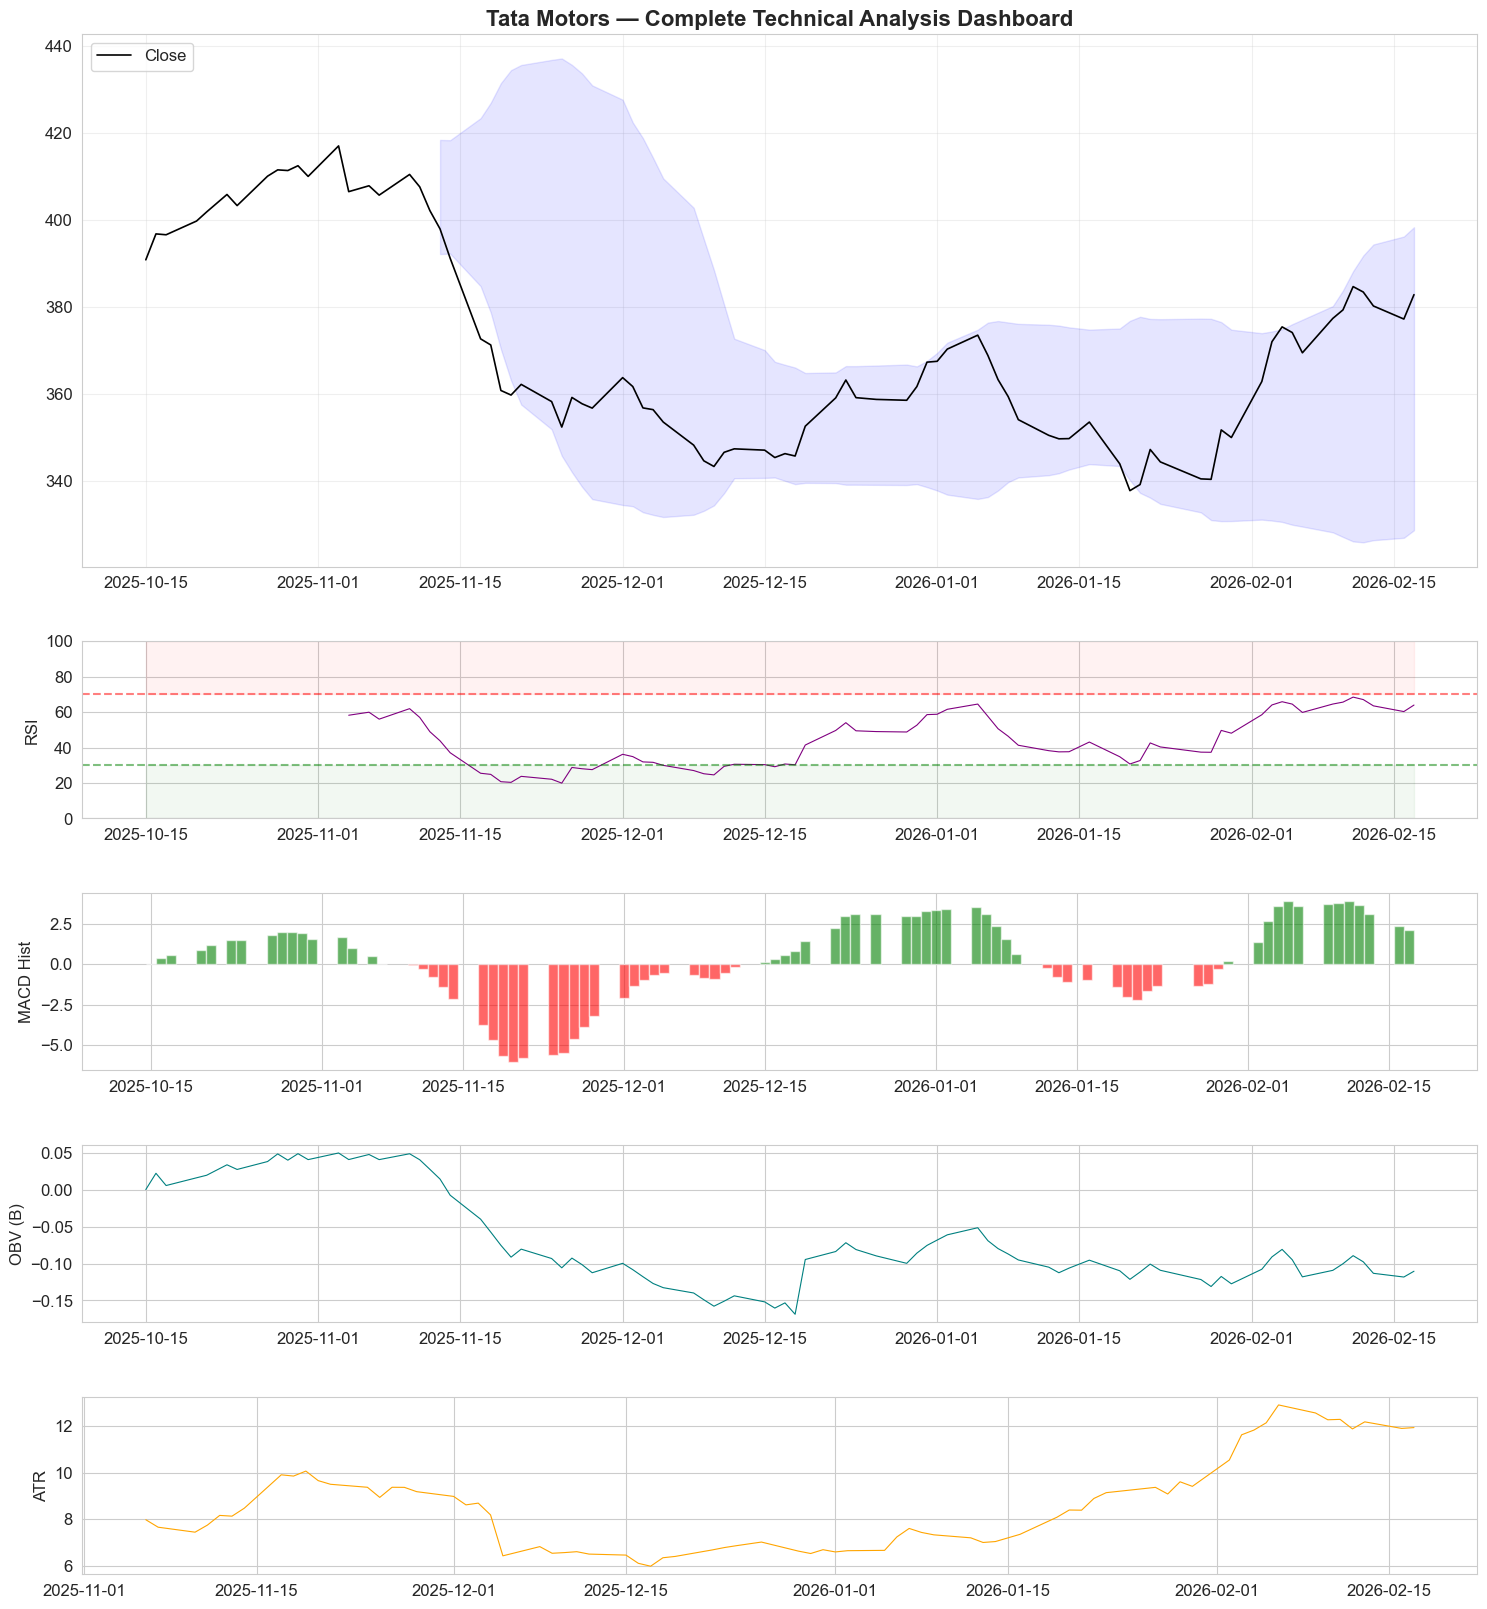

In [19]:
# Complete Technical Dashboard
fig = plt.figure(figsize=(18, 20))
gs = gridspec.GridSpec(5, 1, height_ratios=[3, 1, 1, 1, 1], hspace=0.3)

# Price + Bollinger
ax1 = fig.add_subplot(gs[0])
ax1.plot(df.index, df['Close'], color='black', linewidth=1.2, label='Close')
ax1.fill_between(df.index, df['BB_Upper'], df['BB_Lower'], alpha=0.1, color='blue')
ax1.set_title('Tata Motors — Complete Technical Analysis Dashboard', fontsize=16, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# RSI
ax2 = fig.add_subplot(gs[1])
ax2.plot(df.index, df['RSI_Manual'], color='purple', linewidth=0.8)
ax2.axhline(70, color='red', linestyle='--', alpha=0.5)
ax2.axhline(30, color='green', linestyle='--', alpha=0.5)
ax2.fill_between(df.index, 70, 100, alpha=0.05, color='red')
ax2.fill_between(df.index, 0, 30, alpha=0.05, color='green')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)

# MACD Histogram
ax3 = fig.add_subplot(gs[2])
colors = ['green' if v >= 0 else 'red' for v in df['MACD_Histogram']]
ax3.bar(df.index, df['MACD_Histogram'], color=colors, alpha=0.6, width=1)
ax3.set_ylabel('MACD Hist')

# OBV
ax4 = fig.add_subplot(gs[3])
ax4.plot(df.index, df['OBV'] / 1e9, color='teal', linewidth=0.8)
ax4.set_ylabel('OBV (B)')

# ATR
ax5 = fig.add_subplot(gs[4])
ax5.plot(df.index, df['ATR_14'], color='orange', linewidth=0.8)
ax5.set_ylabel('ATR')

plt.savefig(os.path.join(PROCESSED_DIR, 'technical_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Save the DataFrame with all technical indicators
df.to_csv(os.path.join(PROCESSED_DIR, 'tata_motors_with_technicals.csv'))
print(f"Saved: tata_motors_with_technicals.csv ({df.shape[0]} rows, {df.shape[1]} columns)")
print(f"\nNew columns added: {[c for c in df.columns if c not in ['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close', 'Regime']]}")

Saved: tata_motors_with_technicals.csv (85 rows, 30 columns)

New columns added: ['Returns', 'Price_Change', 'Gain', 'Loss', 'Avg_Gain', 'Avg_Loss', 'RS', 'RSI_Manual', 'EMA_12', 'EMA_26', 'MACD_Line', 'Signal_Line', 'MACD_Histogram', 'BB_Middle', 'BB_Std', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_Upper_Touch', 'BB_Lower_Touch', 'OBV', 'OBV_Normalized', 'TR', 'ATR_14']


---

## 📌 Phase 2 Insight: The Alpha Factory — Don't Feed Raw Prices

> **The 50-Year Veteran says:** *"I look for momentum and exhaustion."*  
> **The Data Scientist says:** *"I create vectors that represent momentum and mean reversion."*

### Why Raw Prices Are Bad Features
Never feed raw prices into XGBoost. Feed it **stories encoded as numbers**:

1. **Lag Features:** Today's price is correlated with recent history
   - `t-1` (yesterday), `t-5` (one week), `t-21` (one month)
2. **Technical Indicators as Features:** RSI, MACD, Bollinger Bands, ATR
3. **Rolling Statistics:** `rolling_mean` and `rolling_std` over 20 and 50 days

The rolling statistics teach the model what **"normal" looks like** for each specific time period. A price that's 2σ above its 20-day mean is behaving unusually — that's a feature, not a prediction.

> **Key Principle:** Transform raw data into *relative* measures (deviations from moving averages, rate of change, z-scores) rather than absolute values.


In [21]:
# Lag Feature Creation (concept demonstration)
# These become input features for ML models in later notebooks

print('LAG FEATURE ENGINEERING')
print('=' * 50)

lag_periods = [1, 5, 21]  # yesterday, 1-week, 1-month
for lag in lag_periods:
    col_name = f'Close_Lag_{lag}'
    df[col_name] = df['Close'].shift(lag)
    print(f'  Created: {col_name} (t-{lag})')

# Percentage change lags (more useful than absolute lags)
for lag in lag_periods:
    col_name = f'Return_Lag_{lag}'
    df[col_name] = df['Close'].pct_change(lag)
    print(f'  Created: {col_name} ({lag}-day return)')

print(f'\nTotal new lag features: {len(lag_periods) * 2}')
print('\nSample lag correlations with next-day return:')
next_day = df['Close'].pct_change().shift(-1)
for lag in lag_periods:
    corr = df[f'Return_Lag_{lag}'].corr(next_day)
    print(f'  Return_Lag_{lag} correlation: {corr:.4f}')


LAG FEATURE ENGINEERING
  Created: Close_Lag_1 (t-1)
  Created: Close_Lag_5 (t-5)
  Created: Close_Lag_21 (t-21)
  Created: Return_Lag_1 (1-day return)
  Created: Return_Lag_5 (5-day return)
  Created: Return_Lag_21 (21-day return)

Total new lag features: 6

Sample lag correlations with next-day return:
  Return_Lag_1 correlation: 0.1668
  Return_Lag_5 correlation: 0.1909
  Return_Lag_21 correlation: 0.0185


## 8. Summary

### Indicators Calculated:
| Indicator | Formula | Signal |
|-----------|---------|--------|
| **RSI** | $100 - \frac{100}{1+RS}$ | Overbought (>70) / Oversold (<30) |
| **MACD** | $EMA_{12} - EMA_{26}$ | Crossover signals |
| **Bollinger Bands** | $SMA_{20} \pm 2\sigma$ | Volatility breakouts |
| **OBV** | Cumulative signed volume | Volume-price divergence |
| **ATR** | $SMA_{14}(TR)$ | Volatility magnitude |

### Key Findings:
- All indicators confirmed the severity of both the COVID crash and Oct 2024 crash
- RSI oversold signals during COVID crash preceded a massive rally
- OBV divergence analysis may reveal "smart money" patterns before Oct 2024

---
*Next: Notebook 04 — Statistical Feature Engineering*
